In [1]:
import yaml
from pathlib import Path
from msm_agent.stage import run_stage1_featurization, run_stage2_tica_scan, run_stage3_tica_fit, run_stage4_cluster, run_stage5_msm_scan, run_stage6_msm_fit, run_stage7_lumpeval

In [ ]:
from msm_agent.config import AgentConfig
import os
cfg = AgentConfig()
cfg.data.kind = "xtc"
cfg.data.dir = "../data/ala2"
cfg.data.topology = "../data/ala2/alanine-dipeptide-nowater.pdb"
cfg.run_dir = "./runs/debug_run_0802"
os.makedirs(Path(cfg.run_dir), exist_ok=True)

In [3]:
cfg.features.type = "angle"
cfg.features.selection = ["phi", "psi","omega"]
cfg.features.atom_selection = "name CA"

In [4]:
cfg.features.type = "distance"
cfg.features.selection = "distances"
cfg.features.atom_selection = "not element H"

In [4]:
re1 = run_stage1_featurization(cfg, Path(cfg.run_dir))

In [5]:
re1

{'success': True,
 'stage': 'stage1_featurization',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 1 completed: data loading and featurization finished.\nRun dir: runs/debug_run_0802\nData kind: xtc\nNumber of trajectories: 3\nEffective timestep: 1.0000 ps\nFeature type: distance\nFeature selection: distances\nAtom selection: not element H\nTrajectory length range (frames): min=250000, max=250000\nFeature dimension(s): [45]\nFraction of pairs in contact: 1.0\nSaved features: runs/debug_run_0802/features\n\nPlease review featurization results. Feature dimension shuold be adequate to capture conformational changes.\nBut too high dimensional features turns noisy and hard to handle.',
 'plot_path': None}

In [5]:
cfg.tica.lag_time_frames_range = [1,100]
cfg.tica.n_components = 3

In [5]:
re2 = run_stage2_tica_scan(cfg, Path(cfg.run_dir))

/Volumes/mobile/agent/MSM-AGENT/msm_agent/metrics.py:71: UserWarning: ITS for lag 0.001 has only 3 timescales, less than top_k=4. Setting top_k to 3 for plateau check.
  warnings.warn(f"ITS for lag {key} has only {len(val)} timescales, less than top_k={top_k}. Setting top_k to {len(val)} for plateau check.")


In [6]:
re2

{'success': True,
 'stage': 'stage2_tica_param_scan',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 2 completed: tICA parameter scan finished.\nRun dir: runs/debug_run_0802\nScan lag range (in frames): 1 to 100\nScan n_components: 3\nEffective timestep: 0.001000 ns\nITS plot: runs/debug_run_0802/figs/tica_its_curve.png\nAuto plateau check: for top 3 components, the last 4 steps are [ True  True  True]\nRecommendation: ITS plateaued for selected components, recommended selected_lag_time for proceed: 6.\nRecommendation: recommended selected_n_component for proceed: 3\n\nPlease review the results for tICA parameter scan. Set selected_lag_time and selected_n_components in TICAConfig to proceed.',
 'plot_path': ['runs/debug_run_0802/figs/tica_its_curve.png']}

In [6]:
cfg.tica.selected_lag_time = 6
cfg.tica.selected_n_components = 3

In [8]:
re3 = run_stage3_tica_fit(cfg, Path(cfg.run_dir))

In [9]:
re3

{'success': True,
 'stage': 'stage3_tica_fit',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 3 completed: final tICA fit finished.\nRun dir: runs/debug_run_0802\nSelected lag_time (frames): 6\nSelected n_components: 3\nSaved tICA trajectories: runs/debug_run_0802/tica_trajs\ntICA trajectory shapes: [[250000, 3], [250000, 3], [250000, 3]]\nDensity plot: runs/debug_run_0802/figs/tica_density_hexbin.png\n\nPlease review the final tICA results. Conformations in a good tICA projection should be well separated.\nRevise your tICA results if the projectoins are heavily overlapping.',
 'plot_path': ['runs/debug_run_0802/figs/tica_density_hexbin.png']}

In [11]:
re4 = run_stage4_cluster(cfg, Path(cfg.run_dir))

In [12]:
re4

{'success': True,
 'stage': 'stage4_cluster',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 4 completed: clustering finished.\nRun dir: runs/debug_run_0802\nCluster type: KMeans\nCluster n_clusters: 200\nSaved clustered trajectories: runs/debug_run_0802/cluster_trajs\nOccupied clusters: 200 out of 200 total clusters\nTiny clusters (occupancy < 10): 0.0000 fraction\n\nPlease review the clustering results. \nA good clustering assignment should be evenly populated with a small fraction of tiny clusters.',
 'plot_path': ['runs/debug_run_0802/figs/occupancy_hist.png']}

In [6]:
re5 = run_stage5_msm_scan(cfg, Path(cfg.run_dir))

In [7]:
re5

{'success': True,
 'stage': 'stage5_msm_scan',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 5 completed: MSM scanning finished.\nRun dir: runs/debug_run_0802\nRecommendation: ITS plateaued for selected components, recommended selected_lag_time for proceed: 3.\nRecommendation: recommended selected_n_component for proceed: 3\n\nPlease review the MSM quality metrics.\nA good microstate MSM should be markovian indicated by passing CK test and plateaued ITS.\nA good microstate MSM should preserve meaningful transitions indicated by no disconnected states.\nSet selected_lag_time and selected_n_timescales in microMSMConfig to proceed.',
 'plot_path': ['runs/debug_run_0802/figs/microstateMSM_its_curve.png']}

In [7]:
cfg.microMSM.selected_lag_time = 3
cfg.microMSM.selected_n_timescales = 3

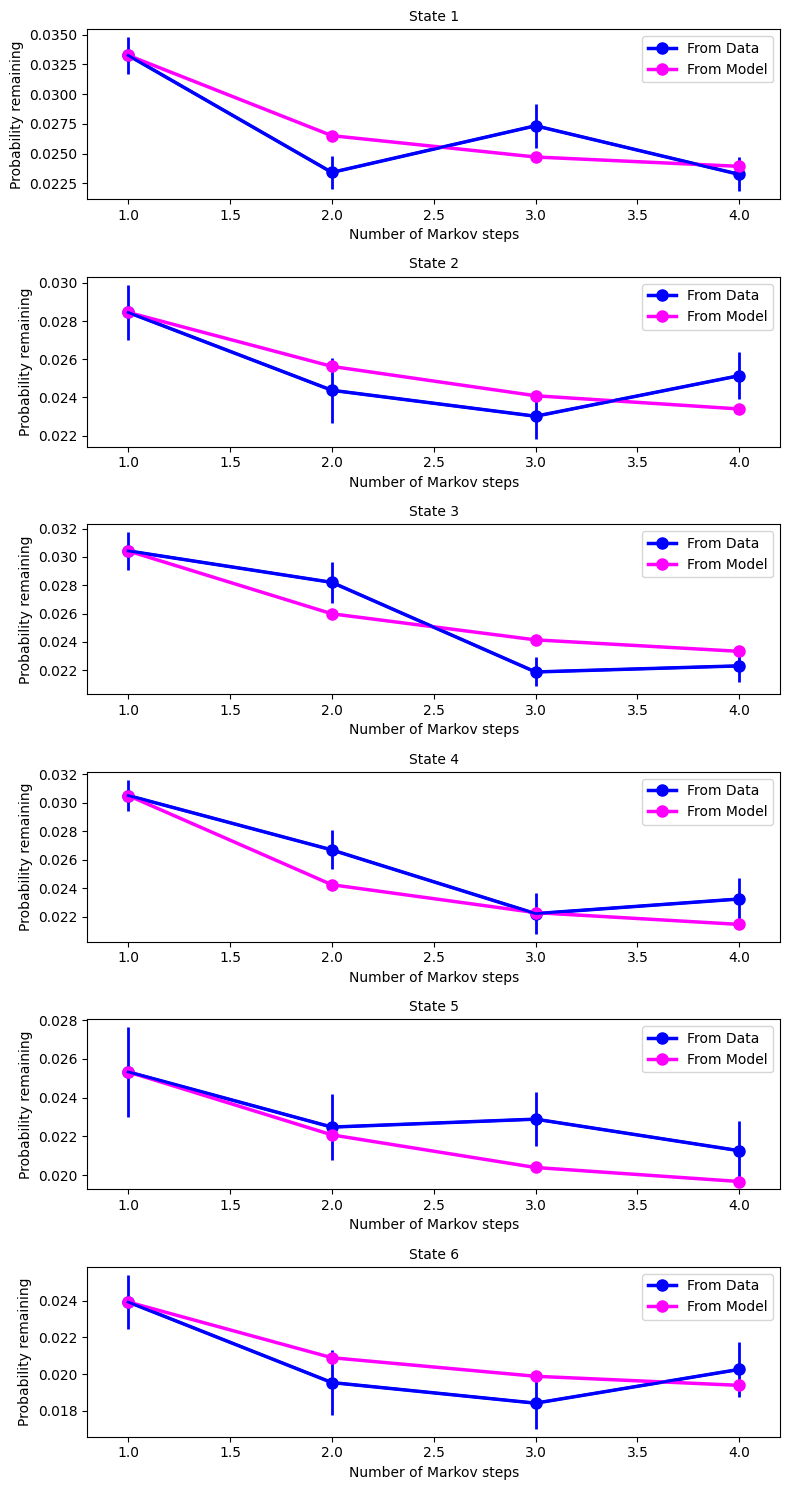

In [11]:
re6 = run_stage6_msm_fit(cfg, Path(cfg.run_dir))

In [12]:
re6

{'success': True,
 'stage': 'stage6_msm_fit',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 6 completed: microstateMSM fit and quality test finished.\nRun dir: runs/debug_run_0802\nCaptured timescales (ns): [1.3314039  0.0619735  0.02393627]\nCK test pass: True with note prediction outside the 95% confidence interval but acceptable\n\nPlease review the MSM test results.\nSet n_macrostates in macroMSMConfig refering to the number of separated timescales brfore proceeding.\nMacrostate MSM works well for capturing the kinetics with top well separated timescales in microstate MSM ITS.\nResults can turn noisy if n_macrostates is too large\nNote that the estimated timescales will be slower after lumping.',
 'plot_path': ['runs/debug_run_0802/figs/CK_test.png',
  'runs/debug_run_0802/figs/weighted_freeenergy.png']}

In [7]:
cfg.microMSM

microMSMConfig(lag_time_frames_range=[1, 50], lag_time_frames_grid_size=20, n_timescales=None, reversible_type='transpose', ergodic_cutoff=False, selected_lag_time=3, selected_n_timescales=3, micro_assign_path=None)

In [8]:
re7 = run_stage7_lumpeval(cfg, Path(cfg.run_dir))

/opt/anaconda3/envs/agent/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


Optimization terminated successfully.
         Current function value: -3.823597
         Iterations: 9
         Function evaluations: 98


/opt/anaconda3/envs/agent/lib/python3.11/site-packages/msmbuilder/msm/msm.py:183: UserWarning: reversible_type='mle' and ergodic_cutoff <= 0 are not generally compatible
  warnings.warn("reversible_type='mle' and ergodic_cutoff <= 0 "


In [9]:
re7

{'success': True,
 'stage': 'stage7_lumpeval',
 'run_dir': 'runs/debug_run_0802',
 'summary': 'Stage 7 completed: macrostate analysis finished.\nRun dir: runs/debug_run_0802\nNumber of macrostates: 4\nMacrostate populations: [1104, 21287, 244908, 482701]\nCaptured timescales (ns): [1.32900431 0.0529013  0.02367359]\n\nPlease review the macrostate analysis results.',
 'plot_path': None}

In [10]:
from msm_agent.config import save_config
save_config(cfg, Path(cfg.run_dir) / "config.yaml")